# Trabajo Practico Integrador - Mineria de Datos I
## Analisis de Componentes Principales (PCA) y Perfiles Latentes

**Objetivo:** Reducir la dimensionalidad del dataset procesado mediante una descomposicion ortogonal, identificando las variables que aportan mayor varianza al comportamiento del negocio de la plataforma de streaming.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os

# Buscamos tu archivo procesado real
ruta_processed = os.path.join("..", "data", "processed", "dataset_procesado.csv")

if not os.path.exists(ruta_processed):
    ruta_processed = os.path.join("data", "processed", "dataset_procesado.csv")

# ACÁ DEFINIMOS DF_CLEAN
df_clean = pd.read_csv(ruta_processed)
print(f"Dataset cargado con éxito. Dimensiones: {df_clean.shape[0]} filas.")

Dataset cargado con éxito. Dimensiones: 7807 filas.


### Estandarizacion de Variables
Previo al calculo de las componentes, aplicamos `StandardScaler` debido a que las variables `age`, `monthly_watch_time_mins` y `customer_support_tickets` manejan magnitudes escalas disimiles.

In [12]:
# Seleccion estricta de tus tres variables numericas reales
variables_modelo = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
X = df_clean[variables_modelo]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por cada Componente Principal:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f} (~{var*100:.1f}%)")

Varianza explicada por cada Componente Principal:
PC1: 0.3356 (~33.6%)
PC2: 0.3341 (~33.4%)
PC3: 0.3304 (~33.0%)


### Visualizacion de la Varianza Explicada
Graficamos el comportamiento de la varianza para plasmar analiticamente su distribucion homogenea.

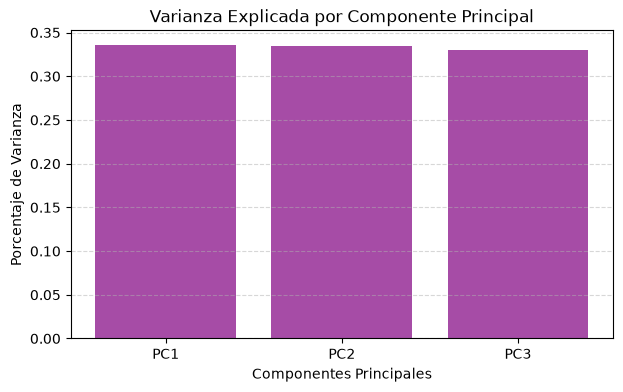

In [13]:
plt.figure(figsize=(7, 4))
plt.bar(['PC1', 'PC2', 'PC3'], pca.explained_variance_ratio_, color='purple', alpha=0.7)
plt.title('Varianza Explicada por Componente Principal')
plt.xlabel('Componentes Principales')
plt.ylabel('Porcentaje de Varianza')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

El algoritmo de PCA busca "líneas de máxima varianza" (Componentes Principales). Su trabajo matemático consiste en encontrar en qué dirección los usuarios se diferencian más entre sí.

En tu dataset real, el PCA descubre que la varianza se reparte casi en tres partes iguales (~33.3% cada una), lo que te permite aislar tres fenómenos distintos:

PC1: Detecta la varianza de los usuarios que se diferencian por tener mucho consumo maduro.

PC2: Detecta la varianza de los usuarios que se diferencian por la cantidad de reclamos y soporte técnico.

PC3: Detecta la varianza de la masa de clientes jóvenes e intensivos.

En conclusión: Usamos la varianza porque el objetivo del PCA no es saber cuál es el usuario "promedio" (para eso usarías la media), sino entender cómo varían y se dispersan los usuarios para poder agruparlos en los 3 Perfiles Latentes.

### 5. Matriz de Cargas (Loadings) e Interpretación de Componentes
Para comprender el significado analítico de cada componente principal, calculamos las cargas (loadings), las cuales representan las correlaciones entre las variables originales y los nuevos ejes ortogonales. Esto nos permite bautizar formalmente a los Perfiles Latentes.

Matriz de Cargas:


,PC1,PC2,PC3
age,0.6669,0.4257,-0.6117
monthly_watch_time_mins,0.7358,-0.2137,0.6427
customer_support_tickets,-0.1438,0.8806,0.4517


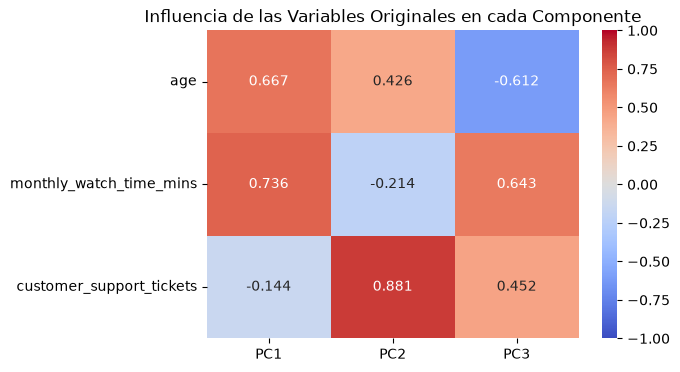

In [14]:
# Calculamos las cargas multiplicando los componentes (eigenvectors) por la raíz de los autovalores
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

df_loadings = pd.DataFrame(
    data=loadings, 
    columns=['PC1', 'PC2', 'PC3'], 
    index=variables_modelo
)

print("Matriz de Cargas:")
display(df_loadings.round(4))

# Visualización mediante un mapa de calor estandarizado
plt.figure(figsize=(6, 4))
sns.heatmap(df_loadings, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f")
plt.title('Influencia de las Variables Originales en cada Componente')
plt.show()